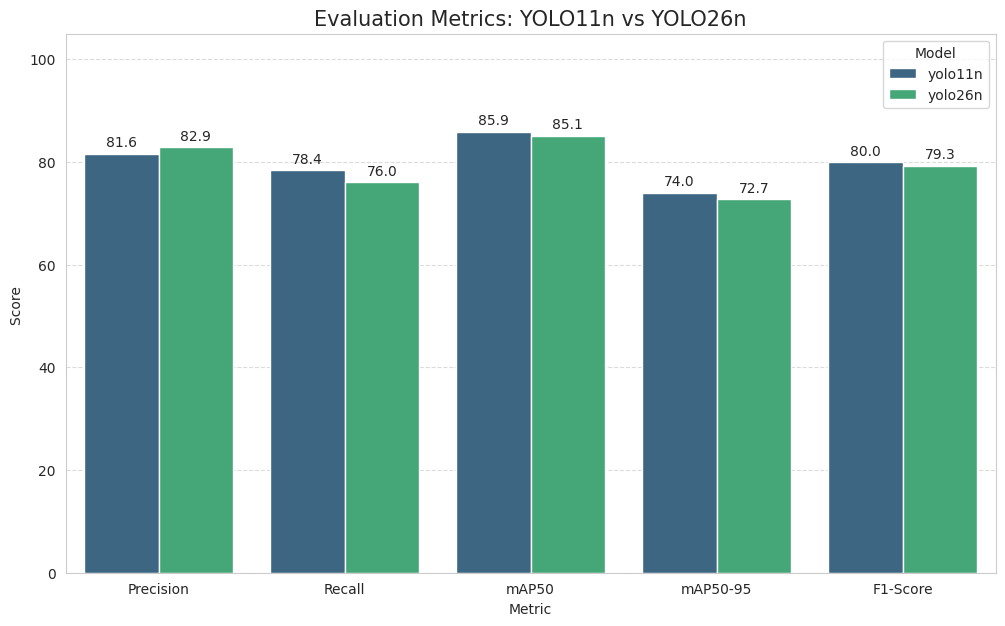

     Model  Precision  Recall  mAP50  mAP50-95  F1-Score
0  yolo11n      81.60   78.44  85.91     74.04     79.99
1  yolo26n      82.88   76.04  85.10     72.74     79.31


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

BASE_PATH = "/kaggle/input/notebooks/angeltamang/baselines/runs/detect/Helmet_Detection_Comparison"
OUTPUT_DIR = "/kaggle/working/evaluation_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

metrics_list = []

# Metrics plot
for m_name in ["yolo11n", "yolo26n"]:
    csv_path = f"{BASE_PATH}/{m_name}/results.csv"
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()

        # Fitness score used by ultrlytics for best model
        df['fitness'] = df['metrics/mAP50(B)'] * 0.1 + df['metrics/mAP50-95(B)'] * 0.9
        best_idx = df['fitness'].idxmax()
        row = df.loc[best_idx]
        
        # Store essential metrics scaled to 0-100
        metrics_list.append({
            'Model': m_name,
            'Precision': row['metrics/precision(B)'] * 100,
            'Recall': row['metrics/recall(B)'] * 100,
            'mAP50': row['metrics/mAP50(B)'] * 100,
            'mAP50-95': row['metrics/mAP50-95(B)'] * 100,
            'F1-Score': (2 * row['metrics/precision(B)'] * row['metrics/recall(B)'] / 
                         (row['metrics/precision(B)'] + row['metrics/recall(B)'])) * 100
        })

# Comparison df
comparison_df = pd.DataFrame(metrics_list)
plot_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.title('Evaluation Metrics: YOLO11n vs YOLO26n', fontsize=15)
plt.ylabel('Score ')
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(f"{OUTPUT_DIR}/model_comparison_metrics.png")
plt.show()

print(comparison_df.round(2))

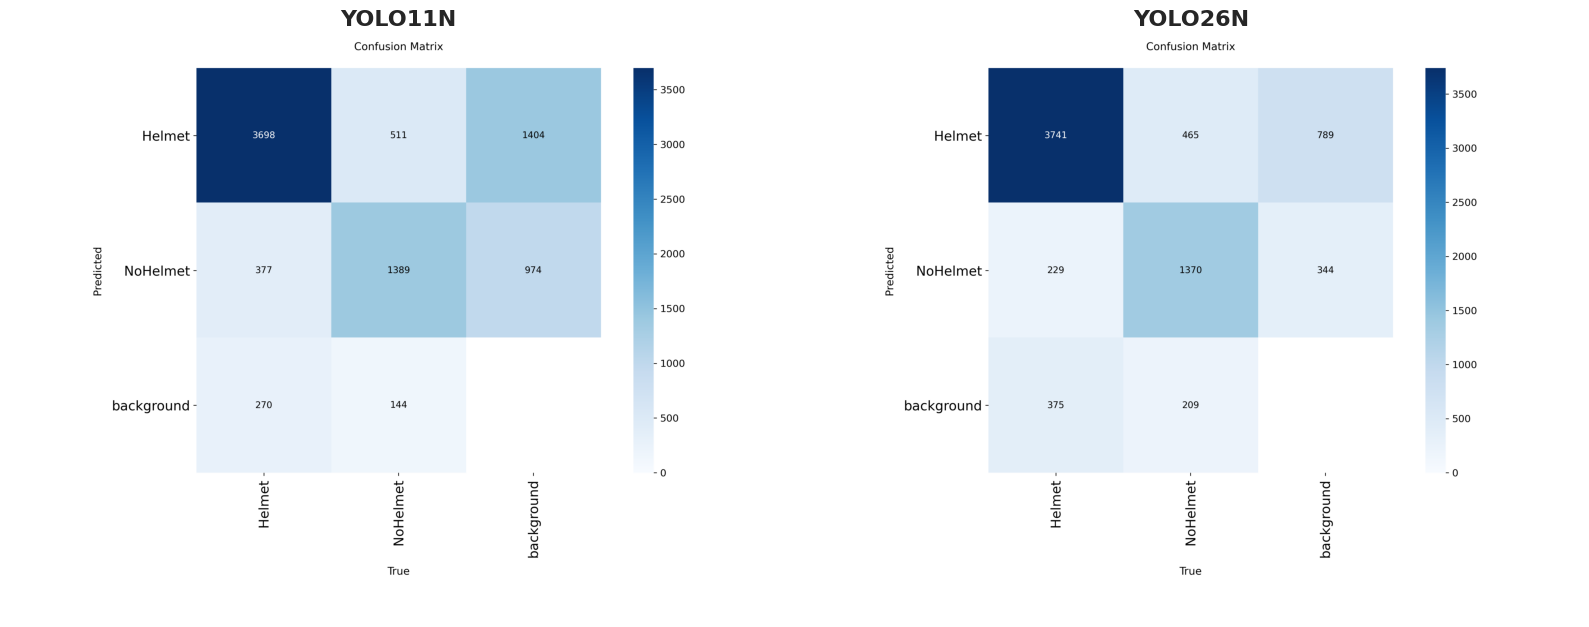

In [2]:
import matplotlib.image as mpimg

models = ["yolo11n", "yolo26n"]

# Confusion Matrix made by ultralytics
fig, axes = plt.subplots(1, 2, figsize=(16, 20))

for i, m_name in enumerate(models):
    img_path = os.path.join(BASE_PATH, m_name, "confusion_matrix.png")
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{m_name.upper()}", fontsize=16, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"File not found:\n{m_name}", 
                     ha='center', va='center', fontsize=12)
        axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Confusion_Matrix_comparison.png")
plt.show()

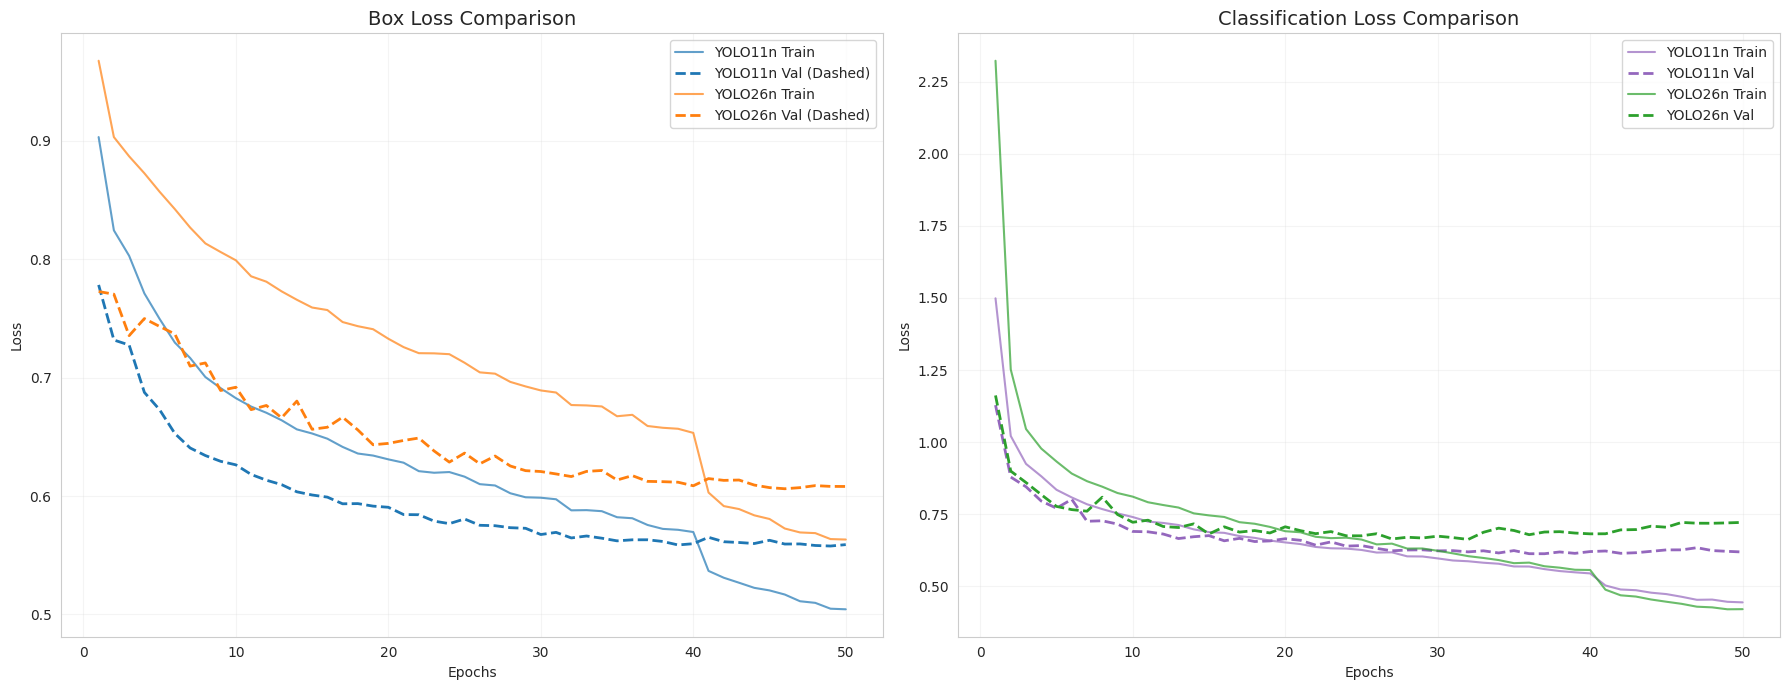

In [3]:
# Losses plots
CSV_11 = f"{BASE_PATH}/yolo11n/results.csv"
CSV_26 = f"{BASE_PATH}/yolo26n/results.csv"

df11 = pd.read_csv(CSV_11)
df11.columns = df11.columns.str.strip()

df26 = pd.read_csv(CSV_26)
df26.columns = df26.columns.str.strip()

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Box Loss 
# YOLO11n curves
ax[0].plot(df11['epoch'], df11['train/box_loss'], label='YOLO11n Train', color='#1f77b4', alpha=0.7)
ax[0].plot(df11['epoch'], df11['val/box_loss'], label='YOLO11n Val (Dashed)', color='#1f77b4', linestyle='--', linewidth=2)
# YOLO26n curves
ax[0].plot(df26['epoch'], df26['train/box_loss'], label='YOLO26n Train', color='#ff7f0e', alpha=0.7)
ax[0].plot(df26['epoch'], df26['val/box_loss'], label='YOLO26n Val (Dashed)', color='#ff7f0e', linestyle='--', linewidth=2)

ax[0].set_title('Box Loss Comparison', fontsize=14)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True, alpha=0.2)

# Classification Loss
# YOLO11n curves
ax[1].plot(df11['epoch'], df11['train/cls_loss'], label='YOLO11n Train', color='#9467bd', alpha=0.7)
ax[1].plot(df11['epoch'], df11['val/cls_loss'], label='YOLO11n Val', color='#9467bd', linestyle='--', linewidth=2)
# YOLO26n curves
ax[1].plot(df26['epoch'], df26['train/cls_loss'], label='YOLO26n Train', color='#2ca02c', alpha=0.7)
ax[1].plot(df26['epoch'], df26['val/cls_loss'], label='YOLO26n Val', color='#2ca02c', linestyle='--', linewidth=2)

ax[1].set_title('Classification Loss Comparison', fontsize=14)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_head_to_head_loss.png")
plt.show()

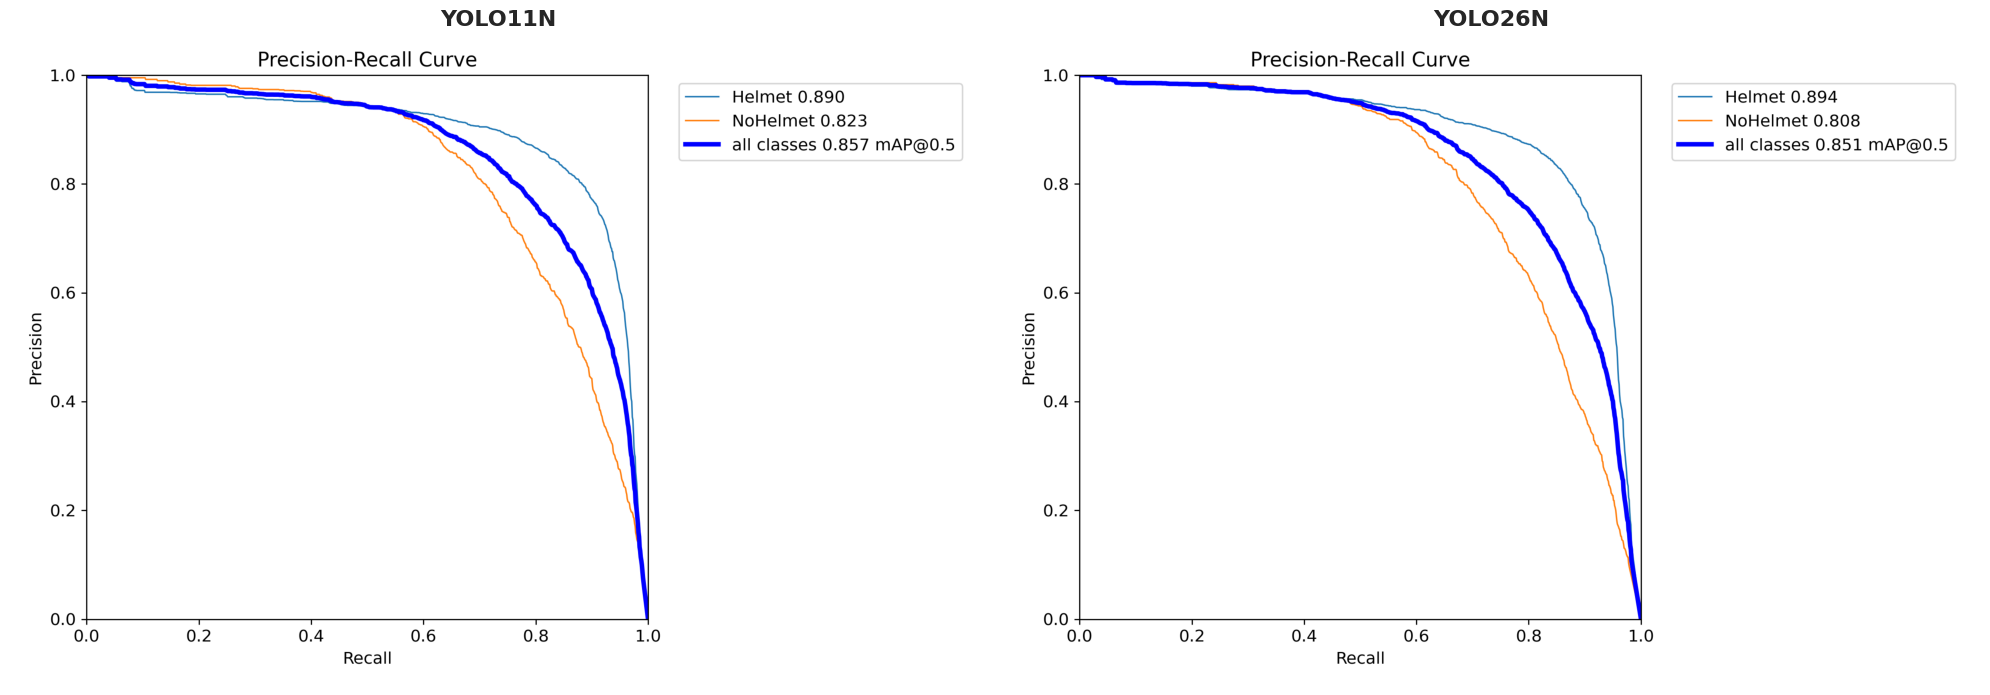

In [4]:
# PR Curves
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i, m_name in enumerate(models):
    img_path = os.path.join(BASE_PATH, m_name, "BoxPR_curve.png")
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{m_name.upper()}", fontsize=16, fontweight='bold')
        axes[i].axis('off') 
    else:
        axes[i].text(0.5, 0.5, f"PR Curve not found for:\n{m_name}", 
                     ha='center', va='center', fontsize=12)
        axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/PR_curve_comparison.png")
plt.show()

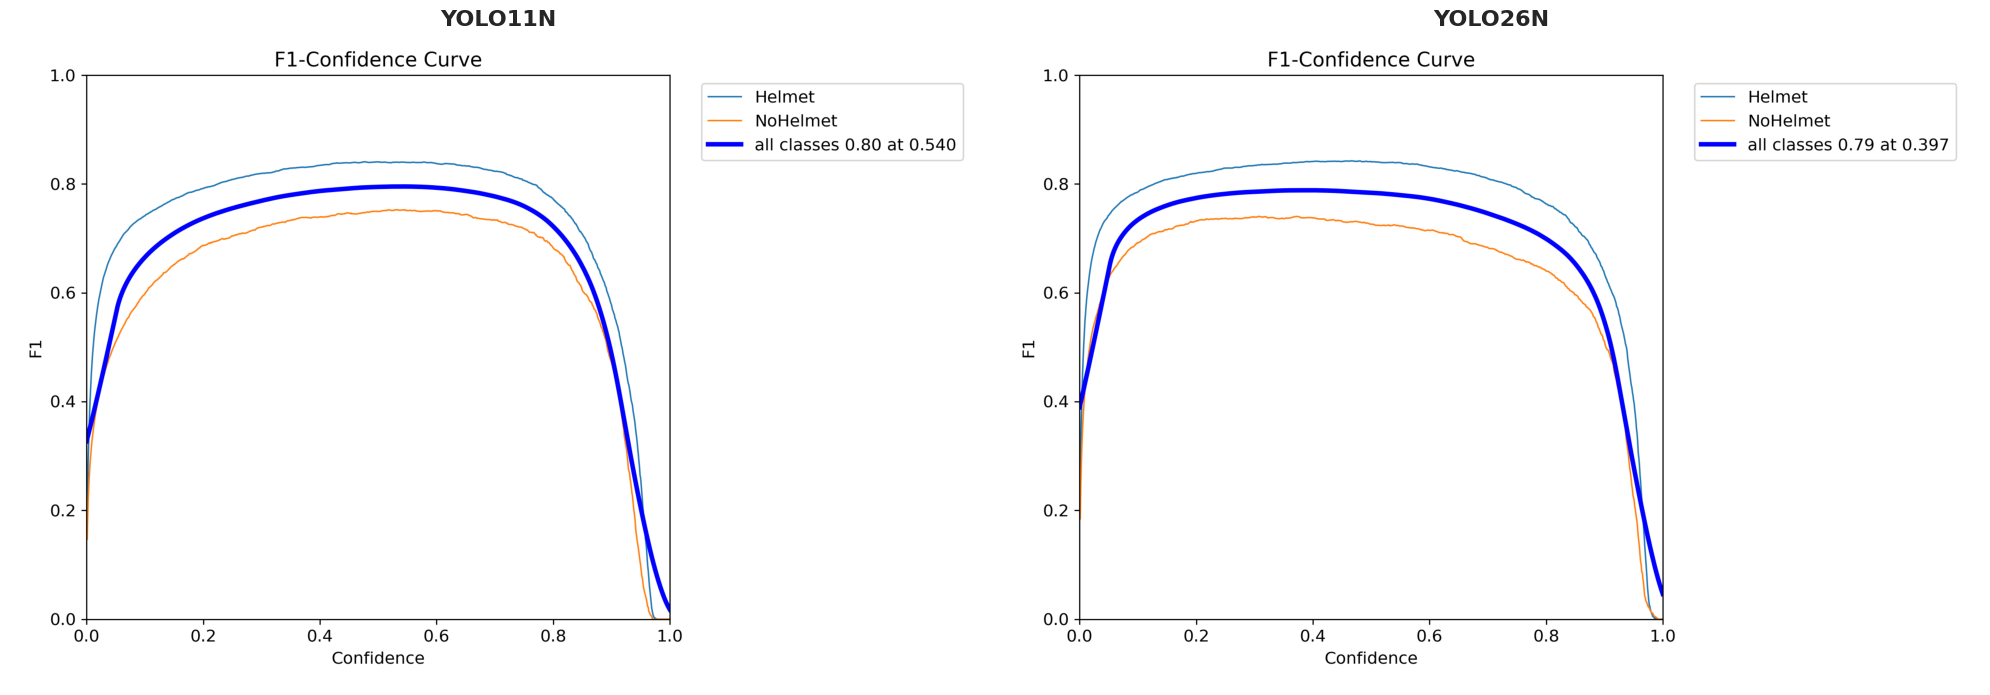

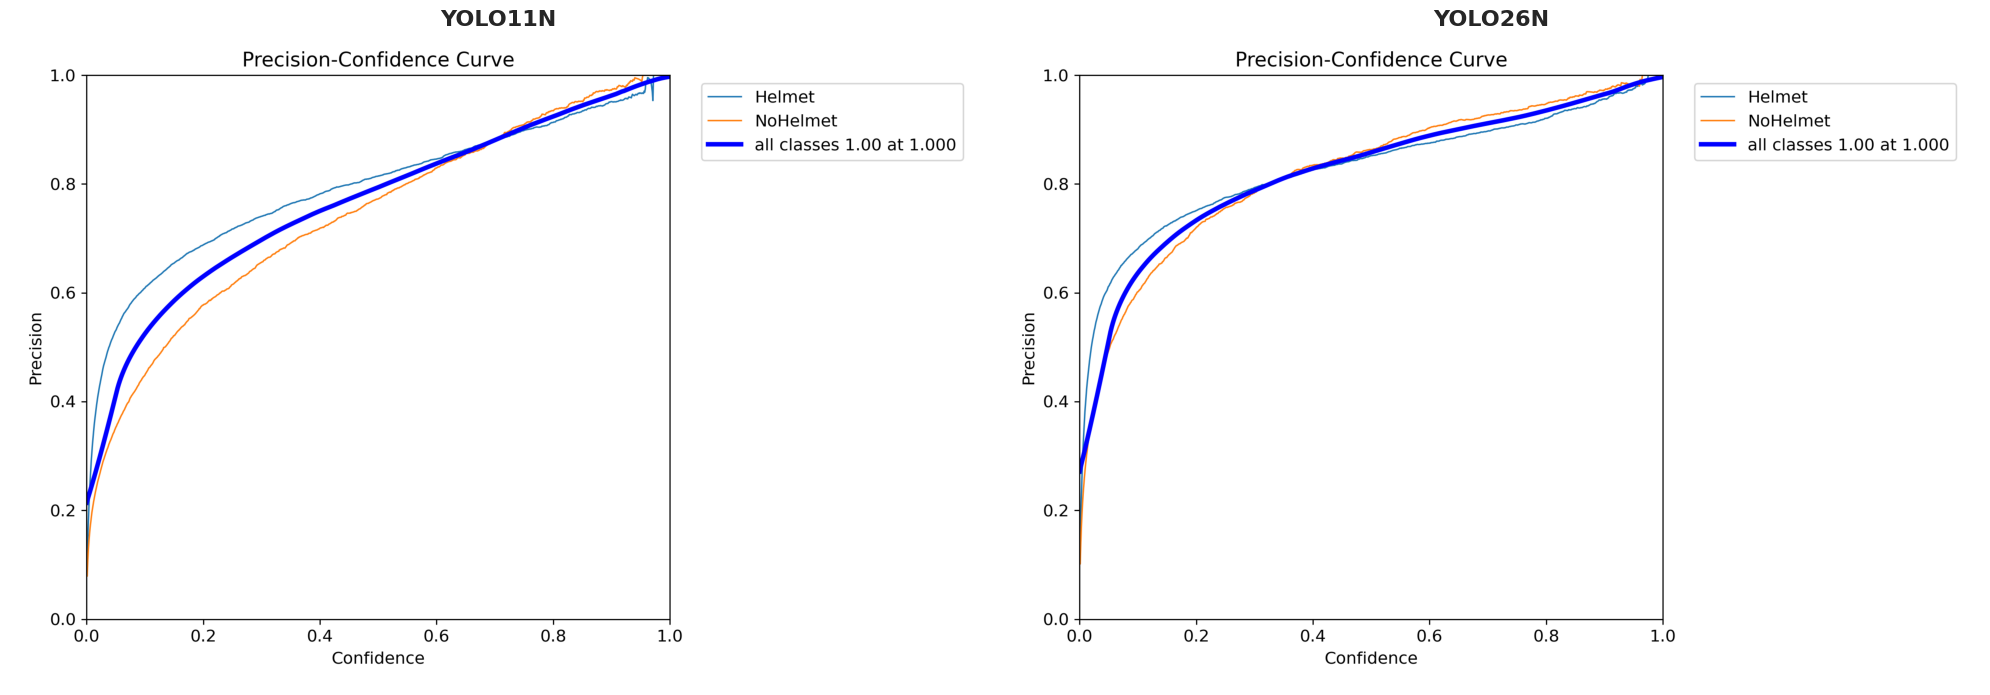

In [5]:
# F1 and Precision Confidence curve
plot_types = ["BoxF1_curve.png", "BoxP_curve.png"] 

for p_type in plot_types:
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    for i, m_name in enumerate(models):
        img_path = os.path.join(BASE_PATH, m_name, p_type)
        
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"{m_name.upper()}", fontsize=16, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f"{p_type} not found for {m_name}", ha='center', va='center')
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{p_type.split(".")[0]}_comparison.png")
    plt.show()